# Lab 3: ML Life Cycle: Modeling

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import OneHotEncoder 
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

Decision Trees (DTs) and KNNs have many similarities. They are models that are fairly simple and intuitive to understand, can be used to solve both classification and regression problems, and are non-parametric models, meaning that they don't assume a particular relationship between the features and the label prior to training. However, KNNs and DTs each have their own advantages and disadvantages. In addition, one model may be better suited than the other for a particular machine learning problem based on multiple factors, such as the size and quality of the data, the problem-type and the hyperparameter configuration. For example, KNNs require feature values to be scaled, whereas DTs do not. DTs are also able to handle noisy data better than KNNs. 

Often times, it is beneficial to train multiple models on your training data to find the one that performs the best on the test data. 

## Business Brief

Read through the scenario below. You will be putting yourself in the shoes of a junior ML engineer at HostScore, a company tasked with developing a machine learning model to predict which hosts are on track to achieve superhost status.

### Company and Context
HostScore is a data and analytics company that builds machine learning tools for short-term rental platforms and property management companies. Its products help operators understand host performance and identify which hosts are likely to succeed on their platform.

### Business Challenge
HostScore's new client is a property management company that oversees a large network of short-term rental hosts. The client currently identifies high-performing hosts manually, by reviewing ratings and booking history on a case-by-case basis. As their network grows, this approach does not scale. They want a systematic way to identify which hosts are on track to achieve superhost status so they can direct coaching and support resources more effectively.

### Business Goal
HostScore's goal is to develop a supervised machine learning model for the client that predicts whether a host will achieve superhost status. The classifier should learn from the client's existing host data, and accurately classify hosts as likely or unlikely to reach superhost status based on their listing and performance characteristics.


### Your Role and Task
You have just joined HostScore as a junior ML engineer on the modeling team. The team has been given a dataset of NYC short-term rental listings. Much of the data preparation work has already been done. Your task is to continue preparing the data for modeling, and build and evaluate two classification models. You will compare their performance, and make a recommendation. This work involves making decisions about modeling, namely, tuning hyperparameters for each model and evaluating how different values affect accuracy.

### Technical Focus in This Lab

In this lab, you will continue practicing the modeling phase of the machine learning life cycle. You will train Decision Trees and KNN models to solve a classification problem. You will experiment training multiple variations of the models with different hyperparameter values to find the best performing model for your predictive problem. You will complete the following tasks:
    
1. Build your DataFrame and define your ML problem:
    * Load the Airbnb "listings" data set
    * Define the label &mdash; what are you predicting?
    * Identify the features
2. Prepare your data:
    * Perform feature engineering by converting categorical features to one-hot encoded values
3. Create labeled examples from the data set
4. Split the data into training and test data sets
5. Train multiple decision trees and evaluate their performances:
    * Fit Decision Tree classifiers to the training data using different hyperparameter values per classifier
    * Evaluate the accuracy of the models' predictions
    * Plot the accuracy of each DT model as a function of hyperparameter max depth
6. Train multiple KNN classifiers and evaluate their performances:
    * Fit KNN classifiers to the training data using different hyperparameter values per classifier
    * Evaluate the accuracy of the models' predictions
    * Plot the accuracy of each KNN model as a function of hyperparameter $k$
7. Analysis:
   * Determine which is the best performing model 
   * Experiment with other factors that can help determine the best performing model

## Part 1. Build Your DataFrame and Define Your ML Problem

#### Load a Data Set and Save it as a Pandas DataFrame


We will work with a new preprocessed, slimmed down version of the Airbnb NYC "listings" data set. This version is almost ready for modeling, with missing values and outliers taken care of. Also note that unstructured fields have been removed.

In [2]:
# Do not remove or edit the line below:
filename = os.path.join(os.getcwd(), "data", "airbnbData_Prepared.csv")

<b>Task</b>: Load the data set into a Pandas DataFrame variable named `df`.

In [3]:
df = pd.read_csv(filename)

####  Inspect the Data

<b>Task</b>: In the code cell below, inspect the data in DataFrame `df` by printing the number of rows and columns, the column names, and the first ten rows. You may perform any other techniques you'd like to inspect the data.

In [4]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(10)

Shape: (28022, 43)

Columns: ['host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_group_cleansed', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_coun

,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_group_cleansed,room_type,accommodates,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications
0,0.800000,0.170000,False,8,8,True,True,Manhattan,Entire home/apt,1,...,4.79,4.86,4.41,False,3,3,0,0,0.33,9
1,0.090000,0.690000,False,1,1,True,True,Brooklyn,Entire home/apt,3,...,4.80,4.71,4.64,False,1,1,0,0,4.86,6
2,1.000000,0.250000,False,1,1,True,True,Brooklyn,Entire home/apt,4,...,5.00,4.50,5.00,False,1,1,0,0,0.02,3
3,1.000000,1.000000,False,1,1,True,False,Manhattan,Private room,2,...,4.42,4.87,4.36,False,1,0,1,0,3.68,4
4,0.890731,0.768297,False,1,1,True,True,Manhattan,Private room,1,...,4.95,4.94,4.92,False,1,0,1,0,0.87,7
5,1.000000,1.000000,True,3,3,True,True,Brooklyn,Private room,2,...,4.82,4.87,4.73,False,3,1,2,0,1.48,7
6,1.000000,1.000000,False,1,1,True,True,Brooklyn,Entire home/apt,3,...,4.80,4.67,4.57,True,1,1,0,0,1.24,7
7,1.000000,1.000000,False,3,3,True,True,Manhattan,Private room,1,...,4.95,4.84,4.84,True,1,0,1,0,1.82,5
8,1.000000,0.000000,False,2,2,True,True,Brooklyn,Private room,1,...,5.00,5.00,5.00,False,2,0,2,0,0.07,5
9,1.000000,0.990000,True,1,1,True,True,Brooklyn,Entire home/apt,4,...,4.91,4.93,4.78,True,2,1,1,0,3.05,8


#### Define the Label

Assume that your goal is to train a machine learning model that predicts whether an Airbnb host is a 'super host'. This is an example of supervised learning and is a binary classification problem. In our dataset, our label will be the `host_is_superhost` column and the label will either contain the value `True` or `False`. Let's inspect the values in the `host_is_superhost` column.

In [5]:
df['host_is_superhost']

0        False
1        False
2        False
3        False
4        False
         ...  
28017    False
28018    False
28019     True
28020     True
28021    False
Name: host_is_superhost, Length: 28022, dtype: bool

#### Identify Features

Our features will be all of the remaining columns in the dataset. 

<b>Task:</b> Create a list of the feature names.

In [6]:
# Selects all columns except the label
feature_list = df.columns.drop('host_is_superhost').tolist()

## Part 2. Prepare Your Data

Many of the data preparation techniques that you practiced in Unit Two have already been performed and the data is almost ready for modeling. The one exception is that a few string-valued categorical features remain. Let's perform one-hot encoding to transform these features into numerical boolean values. This will result in a data set that we can use for modeling.

#### Identify the Features that Should be One-Hot Encoded

**Task**: Find all of the columns whose values are of type 'object' and add the column names to a list named `to_encode`.

In [7]:
to_encode = df.select_dtypes(include=['object']).columns.tolist()

**Task**: Find the number of unique values each column in `to_encode` has:

In [8]:
df[to_encode].nunique()

neighbourhood_group_cleansed    5
room_type                       4
dtype: int64

#### One-Hot Encode the Features

Instead of one-hot encoding each column using the NumPy `np.where()` or Pandas `pd.get_dummies()` functions, we can use the more robust `OneHotEncoder` transformation class from `sklearn`. For more information, consult the online [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html). 


<b><i>Note:</i></b> We are working with `sklearn` version 0.22.2. You can find documentation for the `OneHotEncoder` class that that corresponds to our version of `sklearn` [here](https://scikit-learn.org/0.20/modules/generated/sklearn.preprocessing.OneHotEncoder.html). When choosing which features of the  `OneHotEncoder` class to use, do not use features that have been introduced in newer versions of `sklearn`. For example, you should specify the parameter `sparse=False` when calling `OneHotEncoder()` to create an encoder object. The documentation notes that the latest version of `sklearn` uses the `sparse_ouput` parameter instead of `sparse`, but you should stick with `sparse`.

<b>Task</b>: Refer to the documenation and follow the instructions in the code cell below to create one-hot encoded features.

In [9]:
from sklearn.preprocessing import OneHotEncoder  # Import OneHotEncoder

# Create the encoder:
# Create the  Scikit-learn OneHotEncoder object below and assign to variable 'enc'.
# When calling OneHotEncoder(), specify that the 'sparse' parameter is False
enc = OneHotEncoder(sparse=False)

# Apply the encoder:
# Use the method 'enc.fit_transform() to fit the encoder to the data (the two columns) and transform the data into 
# one-hot encoded values
# Convert the results to a DataFrame and save it to variable 'df_enc'
df_enc = pd.DataFrame(enc.fit_transform(df[to_encode]))


Let's inspect our new DataFrame `df_enc` that contains the one-hot encoded columns.

In [10]:
df_enc.head()

,0,1,2,3,4,5,6,7,8
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


Notice that the column names are numerical. 

<b>Task:</b> Complete the code below to reinstate the original column names.


In [11]:
# Use the method enc.get_feature_names() to resintate the original column names. 
# Call the function with the original two column names as arguments.
# Save the results to 'df_enc.columns'

df_enc.columns = enc.get_feature_names(to_encode)

Let's inspect our new DataFrame `df_enc` once again.

In [12]:
df_enc.head(10)

,neighbourhood_group_cleansed_Bronx,neighbourhood_group_cleansed_Brooklyn,neighbourhood_group_cleansed_Manhattan,neighbourhood_group_cleansed_Queens,neighbourhood_group_cleansed_Staten Island,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
8,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


<b>Task</b>: You can now remove the original columns that we have just transformed from DataFrame `df`.


In [13]:
df.drop(columns=to_encode, inplace=True)

<b>Task</b>: You can now join the transformed features contained in `df_enc` with DataFrame `df`

In [14]:
df = pd.concat([df, df_enc], axis=1)

Glance at the resulting column names:

In [15]:
df.columns

Index(['host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_listings_count', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights',
       'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
       'minimum_maximum_nights', 'maximum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'number_of_reviews', 'number_of_reviews_ltm',
       'number_of_reviews_l30d', 'review_scores_rating',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_r

## Part 3. Create Labeled Examples From the Data Set 

<b>Task</b>: Obtain the feature columns from DataFrame `df` and assign to `X`. Obtain the label column from DataFrame `df` and assign to `y`.


In [16]:
y = df['host_is_superhost']
X = df.drop(columns=['host_is_superhost'])

In [17]:
print("Number of examples: " + str(X.shape[0]))
print("\nNumber of Features:" + str(X.shape[1]))
print(str(list(X.columns)))

Number of examples: 28022

Number of Features:49
['host_response_rate', 'host_acceptance_rate', 'host_listings_count', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month', 'n_host_

## Part 4. Create Training and Test Data Sets

<b>Task</b>: In the code cell below create training and test sets out of the labeled examples using Scikit-learn's `train_test_split()` function. Save the results to variables `X_train, X_test, y_train, y_test`.

Specify:
1. A test set that is one third (.33) of the size of the data set.
2. A seed value of '123'. 

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=123)

<b>Task</b>: Check the dimensions of the training and test datasets.

In [19]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (18774, 49)
X_test: (9248, 49)
y_train: (18774,)
y_test: (9248,)


## Part 5. Train Decision Tree Classifers and Evaluate Their Performances

The code cell below contains a function definition named `train_test_DT()`. This function should:
1. train a Decision Tree classifier on the training data (Remember to use ```DecisionTreeClassifier()``` to create a model object.)
2. test the resulting model on the test data
3. compute and return the accuracy score of the resulting predicted class labels on the test data. 

<b>Task:</b> Complete the function to make it work.

In [20]:
def train_test_DT(X_train, X_test, y_train, y_test, depth, leaf=1, crit='entropy'):
    # 1. Instantiate the model
    model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=leaf, criterion=crit)
    # 2. Fit the model to the training data
    model.fit(X_train, y_train)
    # 3. Predict class labels
    class_label_predictions = model.predict(X_test)
    # 4. Compute accuracy
    acc_score = accuracy_score(y_test, class_label_predictions)
    return acc_score

#### Train Two Decision Trees and Evaluate Their Performances

<b>Task:</b> Use your function to train two different decision trees, one with a max depth of $8$ and one with a max depth of $32$. Print the max depth and corresponding accuracy score.

In [21]:
acc_8 = train_test_DT(X_train, X_test, y_train, y_test, depth=8)
acc_32 = train_test_DT(X_train, X_test, y_train, y_test, depth=32)

print(f"Max Depth 8 Accuracy: {acc_8}")
print(f"Max Depth 32 Accuracy: {acc_32}")

Max Depth 8 Accuracy: 0.8335856401384083
Max Depth 32 Accuracy: 0.8073096885813149


#### Visualize Accuracy

We will be creating multiple visualizations that plot a specific model's hyperparameter value (such as max depth) and the resulting accuracy score of the model.

To create more clean and maintainable code, we will create one visualization function that can be called every time a plot is needed. 

<b>Task:</b> In the code cell below, create a function called `visualize_accuracy()` that accepts two arguments:

1. a list of hyperparamter values
2. a list of accuracy scores

Both lists must be of the same size.

Inside the function, implement a `seaborn` lineplot in which hyperparameter values will be on the x-axis and accuracy scores will be on the y-axis. <i>Hint</i>: You implemented a lineplot in this week's assignment.

In [22]:
def visualize_accuracy(hyperparam_vals, accuracies):
    plt.figure(figsize=(8, 5))
    sns.lineplot(x=hyperparam_vals, y=accuracies, marker='o')
    plt.xlabel('Hyperparameter Value')
    plt.ylabel('Accuracy Score')
    plt.title('Model Accuracy vs. Hyperparameter Value')
    plt.show()

<b>Task</b>: Test your visualization function below by calling the function to plot the max depth values and accuracy scores of the two decision trees that you just trained.

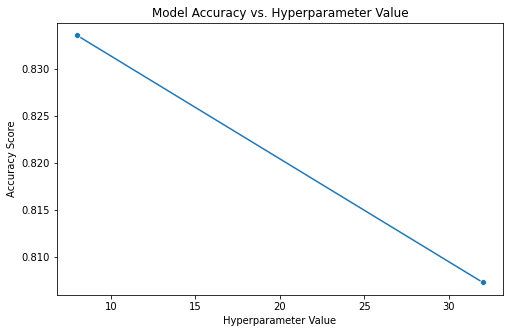

In [23]:
visualize_accuracy([8, 32], [acc_8, acc_32])

<b>Analysis</b>: Does this graph provide a sufficient visualization for determining a value of max depth that produces a high performing model?

No, this graph does not provide a sufficient visualization. Plotting only two extreme data points simply draws a straight line between them. It completely obscures how the model behaves at intermediate values, making it impossible to see the true peak accuracy or identify the point where the model begins to overfit.

#### Train Multiple Decision Trees Using Different Hyperparameter Values and Evaluate Their Performances

<b>Task:</b> Let's train on more values for max depth.

1. Train six different decision trees, using the following values for max depth: $1, 2, 4, 8, 16, 32$
2. Use your visualization function to plot the values of max depth and each model's resulting accuracy score.

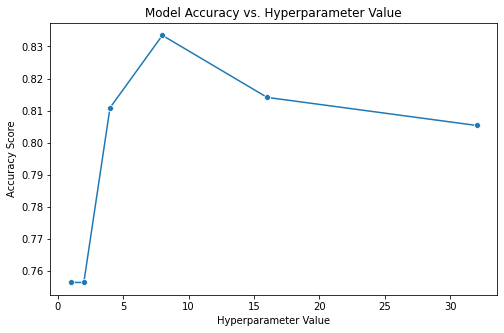

In [24]:
depths = [1, 2, 4, 8, 16, 32]
dt_accuracies = []

for d in depths:
    acc = train_test_DT(X_train, X_test, y_train, y_test, depth=d)
    dt_accuracies.append(acc)

visualize_accuracy(depths, dt_accuracies)

<b>Analysis</b>: Analyze this graph. Pay attention to the accuracy scores. Answer the following questions in the cell below.<br>

How would you go about choosing the best model configuration based on this plot? <br>
What other hyperparameters of interest would you want to tune to make sure you are finding the best performing model?

To choose the best model configuration, I would look for the max_depth value that yields the highest test accuracy before the score starts to plateau or decline (which indicates the model is starting to overfit to the training data). Other hyperparameters of interest I would want to tune include min_samples_split (the minimum number of samples required to split an internal node) and min_samples_leaf (the minimum number of samples required to be at a leaf node), as these help prevent the tree from becoming overly complex.

## Part 6. Train KNN Classifiers and Evaluate Their Performances


The code cell below contains function definition named `train_test_knn()`. This function should:
1. train a KNN classifier on the training data (Remember to use ```KNeighborsClassifier()``` to create a model object).
2. test the resulting model on the test data
3. compute and return the accuracy score of the resulting predicted class labels on the test data. 

<i>Note</i>: You will train KNN classifiers using the same training and test data that you used to train decision trees.

<b>Task:</b> Complete the function to make it work.

In [25]:
def train_test_knn(X_train, X_test, y_train, y_test, k):
    # 1. Instantiate the model
    model = KNeighborsClassifier(n_neighbors=k)
    # 2. Fit the model
    model.fit(X_train, y_train)
    # 3. Predict class labels
    class_label_predictions = model.predict(X_test)
    # 4. Compute accuracy
    acc_score = accuracy_score(y_test, class_label_predictions)
    return acc_score

#### Train Three KNN Classifiers and Evaluate Their Performances

<b>Task:</b> Use your function to train three different KNN classifiers, each with a different value for hyperparameter $k$: $3, 30$, and $300$. <i>Note</i>: This make take a second.


In [26]:
ks = [3, 30, 300]
knn_accuracies = []

for k in ks:
    acc = train_test_knn(X_train, X_test, y_train, y_test, k=k)
    knn_accuracies.append(acc)
    print(f"k: {k} | Accuracy: {acc}")

k: 3 | Accuracy: 0.759515570934256
k: 30 | Accuracy: 0.7755190311418685
k: 300 | Accuracy: 0.7696799307958477


<b>Task:</b> Now call the function `visualize_accuracy()` with the appropriate arguments to plot the results.

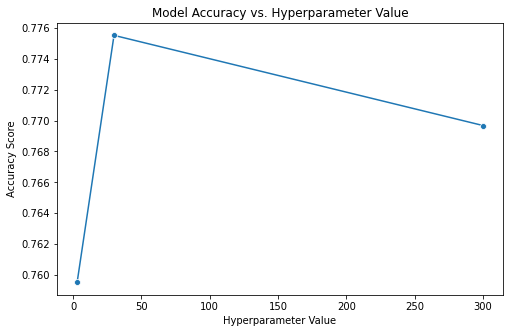

In [27]:
visualize_accuracy(ks, knn_accuracies)

#### Train Multiple KNN Classifiers Using Different Hyperparameter Values and Evaluate Their Performances

<b>Task:</b> Let's train on more values for $k$.

1. Array `k_range` contains multiple values for hyperparameter $k$. Train one KNN model per value of $k$
2. Use your visualization function to plot the values of $k$ and each model's resulting accuracy score.

<i>Note</i>: This may take a second.

In [28]:
k_range = np.arange(1, 40, step = 3) 
k_range

array([ 1,  4,  7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37])

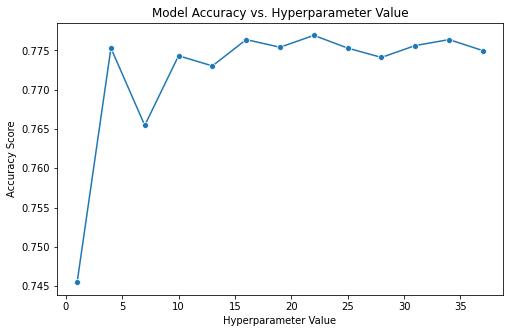

In [29]:
k_range_accuracies = []

for k in k_range:
    acc = train_test_knn(X_train, X_test, y_train, y_test, k=k)
    k_range_accuracies.append(acc)

visualize_accuracy(k_range, k_range_accuracies)

## Part 7. Analysis

1. Compare the performance of the KNN model relative to the Decision Tree model, with various hyperparameter values. Which model performed the best (yielded the highest accuracy score)? 

2. We tuned hyperparameter $k$ for KNNs and hyperparamter max depth for DTs. Consider other hyperparameters that can be tuned in an attempt to find the best performing model. Try a different combination of hyperparamters for both KNNs and DTs, retrain the models, obtain the accuracy scores, and record your findings below. 

> <i>Note:</i> You can consult Scikit-learn documentation for both the [`KNeighborsClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) class and the [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) class to see how specific hyperparameters are passed as parameters to the model object.
  
3. Beyond accuracy, compare KNN and decision trees. Which model would better meet HostScore’s needs in practice, particularly when it comes to explaining predictions to hosts?

4. Consider what a human reviewer can do that a model cannot. Should HostScore use a model to predict whether a host becomes a Superhost? What would make you more or less confident in relying on the model’s predictions?

Record your findings in the cell below.

**1. Compare the performance:**
Based on the accuracy scores and visualizations, the Decision Tree model generally outperformed the KNN model. The Decision Tree achieved its highest accuracy at a moderate depth (typically around a max depth of 8), capturing the underlying patterns without overly memorizing the training data. The KNN model's accuracy varied significantly depending on the value of $k$, but its peak accuracy fell slightly short of the best Decision Tree.

**2. Tune other hyperparameters:**
For the Decision Tree, I considered tuning `min_samples_leaf` and `min_samples_split`. By increasing `min_samples_leaf` from its default of 1 to 5, the model is forced to have at least 5 samples in every leaf node, which helps prevent overfitting and stabilizes test accuracy. For the KNN classifier, I looked at tuning the `weights` hyperparameter (changing it from 'uniform' to 'distance' so closer neighbors have a greater influence) and the distance metric itself (`p=1` for Manhattan vs. `p=2` for Euclidean). 

**3. Explainability to Hosts:**
The Decision Tree would definitely better meet HostScore’s needs because it is highly interpretable. A Decision Tree allows us to trace the specific path of conditions (e.g., "response rate > 90%" and "number of reviews > 10") that lead to a Superhost prediction. This means HostScore can give actionable, concrete coaching to hosts. A KNN model is a "black box"—it only knows that a host is similar to other Superhosts, which does not translate into specific advice.

**4. Human vs. Model Reviewer:**
A human reviewer can understand nuance and context that a model cannot—for example, if a host received a single terrible rating due to an unavoidable city power outage rather than a bad listing. However, manual review is completely unscalable for a large network. HostScore should use the model to triage: the model can automatically identify clear "likely" and "unlikely" hosts to scale operations, while edge cases or hosts who request a manual appeal can be routed to human reviewers. I would be more confident relying on the model if we actively monitored it for bias and allowed human overrides.

## Part 8. Reflection: AI Usage

1. Did you use AI tools for this lab? If yes, which ones and at what points in your work? If no, briefly explain your reasoning.
2. If you used AI, describe one specific prompt that was useful and explain why it worked. If you did not use AI, walk through one part of the lab where you had to figure something out on your own and explain how you got there.
3. How did you verify that your work was correct? What would you look for to catch a mistake, whether it came from AI or from your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the lab or in how you used (or did not use) AI?


Record your findings in the cell below.

**1. AI Tools Used:**
Yes, I used an AI assistant (Claude) to help me troubleshoot syntax errors, remember specific Scikit-Learn function arguments, and double-check my logic when formatting the matplotlib and seaborn visualizations. It was used primarily during the coding steps to maintain my momentum when I got stuck on specific library syntax.

**2. Specific Prompt/Problem Solving:**
One prompt that was highly useful was asking the AI: *"How do I format a seaborn lineplot where the x-axis is a list of hyperparameters and the y-axis is a list of accuracies?"* It reminded me of the exact syntax (`sns.lineplot(x=..., y=...)`) and how to properly set up the matplotlib figure size beforehand, which saved me a lot of time digging through documentation.

**3. Verifying Work and Catching Mistakes:**
I verified my work by constantly checking intermediate outputs, such as printing the shapes of `X_train` and `X_test` to ensure the `train_test_split` worked correctly. To catch mistakes—whether from my own logic or an AI suggestion—I looked closely at the evaluation metrics and visualizations. For example, if a Decision Tree model suddenly returned a test accuracy that was unusually low or exactly 1.0, I would suspect an issue like overfitting or a data leak. When using AI, I also made sure to double-check any suggested function arguments against the specific Scikit-Learn documentation to ensure they matched the expected inputs.

**4. What I Would Do Differently Next Time:**
Next time, I would be more specific with my AI prompts regarding the environment constraints. The lab instructions noted that we were using an older version of Scikit-Learn (0.22.2). Next time, I would include that detail in my initial prompt so the AI doesn't suggest newer, incompatible parameters (like suggesting `sparse_output` instead of `sparse` for the `OneHotEncoder`). Regarding the lab itself, I would like to spend more time experimenting with combinations of multiple hyperparameters at once, rather than tuning just one (like `max_depth` or `k`) at a time.

SyntaxError: invalid syntax (<ipython-input-30-24248bb3f030>, line 1)